In [1]:
import pandas as pd
import missingno as msno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_geolocation = pd.read_csv('olist_geolocation_dataset.csv')
df_order_items = pd.read_csv('olist_order_items_dataset.csv')
df_order_payments = pd.read_csv('olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_products = pd.read_csv('olist_products_dataset.csv')
df_sellers = pd.read_csv('olist_sellers_dataset.csv')
df_category_name_translation = pd.read_csv(
    'product_category_name_translation.csv')

## Description des données

### olist_customers_dataset.csv

In [3]:
df_customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [4]:
# Vérifier l'absence de doublons
df_customers.loc[df_customers['customer_id'].duplicated(keep=False), :]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [5]:
# Vérifier l'absence de doublons
df_customers.loc[df_customers['customer_unique_id'].duplicated(keep=False)]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
13,eabebad39a88bb6f5b52376faec28612,295c05e81917928d76245e842748184d,5704,sao paulo,SP
32,2d5831cb2dff7cdefba62e950ae3dc7b,e9dd12dca17352644a959d9dea133935,42800,camacari,BA
33,b2bed119388167a954382cca36c4777f,e079b18794454de9d2be5c12b4392294,27525,resende,RJ
...,...,...,...,...,...
99324,5b46a0d983eec8c97363bea78d4a69dd,8bab3162259edfaadd1ea2e1fe7f58dc,31565,belo horizonte,MG
99327,c1affa46f9f3b514555259049a0307b9,12ab9334b1240d6d037f2b0102a49571,38050,uberaba,MG
99336,ebf46ff530343a129926adc1f831dea4,0ee57f62666561b72f2ceacad0230cbf,9530,sao caetano do sul,SP
99353,282fbce48e4d2077aad602dd125c9225,0ceb502fc33a2ad327b08288c5310e2e,29134,viana,ES


In [6]:
df_customers['customer_unique_id'].nunique()

96096

96096 clients uniques (unique_id) seuls 3.5% des clients ont plusieurs commandes
99441 clients (customer_id) -> relié à une commande
données géographiqes : zip code préfixe + ville et pays


### olist_geolocation_dataset

In [7]:
df_geolocation

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


In [8]:
df_geolocation['geolocation_zip_code_prefix'].value_counts()

24220    1146
24230    1102
38400     965
35500     907
11680     879
         ... 
71750       1
71742       1
26475       1
26357       1
29826       1
Name: geolocation_zip_code_prefix, Length: 19015, dtype: int64

In [9]:
df_geolocation['geolocation_state'].value_counts()

SP    404268
MG    126336
RJ    121169
RS     61851
PR     57859
SC     38328
BA     36045
GO     20139
ES     16748
PE     16432
DF     12986
MT     12031
CE     11674
PA     10853
MS     10431
MA      7853
PB      5538
RN      5041
PI      4549
AL      4183
TO      3576
SE      3563
RO      3478
AM      2432
AC      1301
AP       853
RR       646
Name: geolocation_state, dtype: int64

In [10]:
df_geolocation['geolocation_city'].value_counts()

sao paulo               135800
rio de janeiro           62151
belo horizonte           27805
são paulo                24918
curitiba                 16593
                         ...  
jacuípe                      1
mar vermelho                 1
quebrangulo                  1
poço das trincheiras         1
poxim                        1
Name: geolocation_city, Length: 8011, dtype: int64

27 pays
8011 villes
19015 zipcode prefix
1000162 lignes

In [11]:
# Vérifier l'absence de doublons
df_geolocation.loc[df_geolocation['geolocation_zip_code_prefix'].duplicated(
    keep=False), :]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


Beaucoup de doublons sur le zip code préfixe : regarder la documentation pour trouver à quoi correspondent les index

### olist_order_items_dataset

In [12]:
df_order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [13]:
df_order_items['order_id'].value_counts()

8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
                                    ..
5a0911d70c1f85d3bed0df1bf693a6dd     1
5a082b558a3798d3e36d93bfa8ca1eae     1
5a07264682e0b8fbb3f166edbbffc6e8     1
5a071192a28951b76774e5a760c8c9b7     1
fffe41c64501cc87c801fd61db3f6244     1
Name: order_id, Length: 98666, dtype: int64

In [14]:
df_order_items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [15]:
df_order_items['order_item_id'].value_counts()

1     98666
2      9803
3      2287
4       965
5       460
6       256
7        58
8        36
9        28
10       25
11       17
12       13
13        8
14        7
15        5
16        3
17        3
18        3
19        3
20        3
21        1
Name: order_item_id, dtype: int64

In [16]:
# Vérifier l'absence de doublons
df_order_items.loc[df_order_items['order_id'].duplicated(keep=False), :]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
13,0008288aa423d2a3f00fcb17cd7d8719,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
14,0008288aa423d2a3f00fcb17cd7d8719,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
32,00143d0f86d6fbd9f9b38ab440ac16f5,1,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
...,...,...,...,...,...,...,...
112635,fff8287bbae429a99bb7e8c21d151c41,2,bee2e070c39f3dd2f6883a17a5f0da45,4e922959ae960d389249c378d1c939f5,2018-03-27 12:29:22,180.00,48.14
112640,fffb9224b6fc7c43ebb0904318b10b5f,1,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112641,fffb9224b6fc7c43ebb0904318b10b5f,2,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112642,fffb9224b6fc7c43ebb0904318b10b5f,3,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19


112650 order items + id du produit, du vendeur, date prix et freight_value
Attention il peut y avoir plusieurs produits par order_id (numéro du produit dans la commande est donné par order_item_id)

### olist_order_payments_dataset

In [17]:
df_order_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [18]:
df_order_payments['payment_sequential'].value_counts()

1     99360
2      3039
3       581
4       278
5       170
6       118
7        82
8        54
9        43
10       34
11       29
12       21
13       13
14       10
15        8
18        6
19        6
16        6
17        6
21        4
20        4
22        3
26        2
24        2
23        2
25        2
29        1
28        1
27        1
Name: payment_sequential, dtype: int64

In [19]:
df_order_payments['payment_installments'].value_counts()

1     52546
2     12413
3     10461
4      7098
10     5328
5      5239
8      4268
6      3920
7      1626
9       644
12      133
15       74
18       27
11       23
24       18
20       17
13       16
14       15
17        8
16        5
21        3
0         2
22        1
23        1
Name: payment_installments, dtype: int64

In [20]:
df_order_payments['payment_type'].value_counts()

credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: payment_type, dtype: int64

103886 payments + id de la commande 

### olist_order_reviews_dataset

In [21]:
df_order_reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [22]:
df_order_reviews['review_score'].value_counts()

5    57328
4    19142
1    11424
3     8179
2     3151
Name: review_score, dtype: int64

{'bodies': [<matplotlib.collections.PolyCollection at 0x1bdf009abb0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x1bdf009ab20>,
 'cmins': <matplotlib.collections.LineCollection at 0x1bdf02212b0>,
 'cbars': <matplotlib.collections.LineCollection at 0x1bdf0221670>}

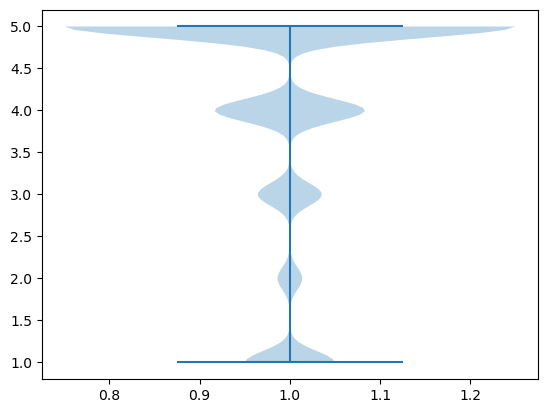

In [23]:
plt.violinplot(df_order_reviews['review_score'])

{'whiskers': [<matplotlib.lines.Line2D at 0x1bdf4cb0ca0>,
 'caps': [<matplotlib.lines.Line2D at 0x1bdf4cbe280>,
 'boxes': [<matplotlib.lines.Line2D at 0x1bdf4cb09d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1bdf4cbe820>],
 'fliers': [<matplotlib.lines.Line2D at 0x1bdf4cbeaf0>],
 'means': []}

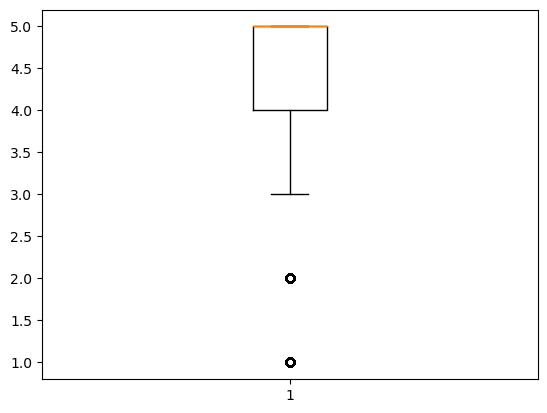

In [24]:
plt.boxplot(df_order_reviews['review_score'])

99224 reviews
identifiants de la review et de la commande + score (de 1 à 5) et message + dates

### olist_orders_dataset.csv

In [25]:
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [26]:
df_orders['order_status'].value_counts()

delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64

In [27]:
df_orders['order_id'].unique

<bound method Series.unique of 0        e481f51cbdc54678b7cc49136f2d6af7
1        53cdb2fc8bc7dce0b6741e2150273451
2        47770eb9100c2d0c44946d9cf07ec65d
3        949d5b44dbf5de918fe9c16f97b45f8a
4        ad21c59c0840e6cb83a9ceb5573f8159
                       ...               
99436    9c5dedf39a927c1b2549525ed64a053c
99437    63943bddc261676b46f01ca7ac2f7bd8
99438    83c1379a015df1e13d02aae0204711ab
99439    11c177c8e97725db2631073c19f07b62
99440    66dea50a8b16d9b4dee7af250b4be1a5
Name: order_id, Length: 99441, dtype: object>

In [28]:
# vérifier l'absence de doublon
df_orders.loc[df_orders[['order_purchase_timestamp']].duplicated(
    keep=False), :]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
30,f70a0aff17df5a6cdd9a7196128bd354,456dc10730fbdba34615447ea195d643,delivered,2017-08-10 11:58:33,2017-08-12 02:45:24,2017-08-17 15:35:07,2017-08-18 14:28:02,2017-08-23 00:00:00
47,25f4376934e13d3508486352e11a5db0,12fd2740039676063a874b9567dfa651,delivered,2018-05-17 16:59:11,2018-05-18 01:17:39,2018-05-18 13:02:00,2018-05-21 15:22:11,2018-05-25 00:00:00
174,ce9feeba53c652dd6569cca62e2bb287,f7398fc942c8fa80e5419ae52e49f7fb,delivered,2018-04-15 19:42:06,2018-04-15 19:55:20,2018-04-19 14:32:30,2018-04-20 23:12:11,2018-04-26 00:00:00
377,6b7c5703bdc03335b37020877a06625e,9ce1401cf82bd5420fe255e02d6292ba,delivered,2017-11-24 01:34:00,2017-11-24 01:49:32,2017-11-30 23:38:27,2017-12-03 15:36:44,2017-12-15 00:00:00
543,6d46f8b7f485ad93146f9880682d4eb2,ed91cd9ea6e333288382a4adbefaffcf,delivered,2017-11-26 11:38:04,2017-11-26 11:54:51,2017-11-27 20:12:00,2017-12-05 19:23:37,2017-12-15 00:00:00
...,...,...,...,...,...,...,...,...
99018,3003eed153ba33c08d9352250d65ba75,e16cf97d3d5183b6516d4fa8a476285c,delivered,2017-06-19 21:27:05,2017-06-19 21:35:23,2017-06-22 13:06:51,2017-07-03 14:07:31,2017-07-19 00:00:00
99047,2fcdb0c004a2a538d3dd724ea76916bd,cf826be53b1fe4a39bc33c7f5f827835,delivered,2017-11-22 11:39:00,2017-11-22 11:49:05,2017-11-23 22:58:51,2017-12-15 00:23:25,2017-12-18 00:00:00
99057,48340ddd156767e80ea7a05abc8a0af4,28689e72c53169610a3d6f96d729b4bd,delivered,2018-05-27 12:30:34,2018-05-27 12:55:38,2018-05-29 14:38:00,2018-06-15 14:36:37,2018-07-23 00:00:00
99187,cf05987956ae425707062444530231d5,9eee5713aa4f4dd1ada4af4da9dfb1fa,delivered,2018-02-24 20:29:18,2018-02-24 21:35:25,2018-02-27 00:07:45,2018-03-01 00:52:57,2018-03-12 00:00:00


In [29]:
df_orders.loc[df_orders['order_id'] == '03caa2c082116e1d31e67e9ae3700499']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
13390,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23 00:00:00


In [30]:
# 99441 commandes / client / statut / dates

### olist_products_dataset

In [31]:
df_products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [32]:
df_products['product_category_name'].value_counts()

cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
fashion_roupa_infanto_juvenil       5
casa_conforto_2                     5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: product_category_name, Length: 73, dtype: int64

In [33]:
# 32951 produits / 73 catégories
# Ensemble des caractéristiques du produit taille, poids + annonce (nb de photos, taille de la description)

### olist_sellers_dataset.csv

In [34]:
df_sellers

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [35]:
len(df_sellers['seller_city'].value_counts())

611

In [36]:
len(df_sellers['seller_state'].value_counts())

23

In [37]:
df_sellers.loc[df_sellers['seller_id'].duplicated(keep=False), :]

,seller_id,seller_zip_code_prefix,seller_city,seller_state


In [38]:
# 3095 vendeurs dans 23 pays et 611 villes
# pas de doublon dans les seller_id

### product_category_name_translation.csv

In [39]:
df_category_name_translation

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [40]:
# Utiliser ce df pour traduire la variable product category name
# 73 catégories dans le df_products, vérifier s'il n'y a pas des doublons avec différence d'écriture

## Regrouper les informations dans un dataframe

In [41]:
# Première sélection de features : RFM : récence, fréquence, montant
# Client ID +
# Récence : df_orders['order_purchase_timestamp']
# Fréquence : df_customers['customer_id', 'customer_unique_id'] (groupby('customer_unique_id'))
# Montant : df_order_items['price']

# Pour chaque df, sélectionner les données pertinentes puis aggréger les données dans un seul df

In [42]:
df_customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [43]:
df_orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [44]:
df_order_payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [45]:
df_order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [46]:
df_order_reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

In [88]:
df1 = df_customers[[
    'customer_id', 'customer_unique_id', 'customer_city', 'customer_state'
]]
df2 = df_orders[['order_id', 'customer_id', 'order_purchase_timestamp']]
df3 = df_order_items[['order_id', 'price']]
df4 = df_order_reviews[[
    'review_id', 'order_id', 'review_score', 'review_comment_message'
]]

In [90]:
df2.loc[df2['order_id'] == '03caa2c082116e1d31e67e9ae3700499']

,order_id,customer_id,order_purchase_timestamp
13390,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,2017-09-29 15:24:52


In [91]:
df_selected_data = df1.merge(df2, how='inner', on='customer_id')

In [93]:
df_selected_data = df_selected_data.merge(df3, how='inner', on='order_id')

In [98]:
df_selected_data.shape

(112650, 7)

In [99]:
df_selected_data = df_selected_data.merge(df4, how='inner', on='order_id')

In [100]:
df_selected_data

,customer_id,customer_unique_id,customer_city,customer_state,order_id,order_purchase_timestamp,price,review_id,review_score,review_comment_message
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,franca,SP,00e7ee1b050b8499577073aeb2a297a1,2017-05-16 15:05:35,124.99,88b8b52d46df026a9d1ad2136a59b30b,4,NaN
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,2018-01-12 20:48:24,289.00,02fc48a9efa3e3d0f1a8ea26507eeec3,5,NaN
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,2018-05-19 16:07:45,139.94,5ad6695d76ee186dc473c42706984d87,5,NaN
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,2018-03-13 16:06:38,149.94,059a801bb31f6aab2266e672cab87bc5,5,NaN
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,2018-07-29 09:51:30,230.00,8490879d58d6c5d7773f2739a03f089a,5,O baratheon è esxelente Amo adoro o baratheon
...,...,...,...,...,...,...,...,...,...,...
112367,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,2018-04-07 15:48:17,74.90,36e2cdbaa9f639b57c53b37ac798fee8,4,NaN
112368,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,2018-04-04 08:20:22,114.90,b273b431c3aedb4eed18643309652940,5,NaN
112369,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,2018-04-08 20:11:50,37.00,fa4f16891e6b2edd1354668d07f5648b,1,Esperava qualidade no atendimento e estou tend...
112370,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,2017-11-03 21:08:33,689.00,0bcdc9e450ea500811a8d39ee993cd47,5,NaN


In [101]:
df_selected_data.isna().sum()

customer_id                     0
customer_unique_id              0
customer_city                   0
customer_state                  0
order_id                        0
order_purchase_timestamp        0
price                           0
review_id                       0
review_score                    0
review_comment_message      64730
dtype: int64

In [102]:
df_selected_data.to_csv('df_selected_data.csv')

# Feature engineering

In [145]:
df_selected_data

,customer_id,customer_unique_id,customer_city,customer_state,order_id,order_purchase_timestamp,price,review_id,review_score,review_comment_message
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,franca,SP,00e7ee1b050b8499577073aeb2a297a1,2017-05-16 15:05:35,124.99,88b8b52d46df026a9d1ad2136a59b30b,4,NaN
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,2018-01-12 20:48:24,289.00,02fc48a9efa3e3d0f1a8ea26507eeec3,5,NaN
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,2018-05-19 16:07:45,139.94,5ad6695d76ee186dc473c42706984d87,5,NaN
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,2018-03-13 16:06:38,149.94,059a801bb31f6aab2266e672cab87bc5,5,NaN
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,2018-07-29 09:51:30,230.00,8490879d58d6c5d7773f2739a03f089a,5,O baratheon è esxelente Amo adoro o baratheon
...,...,...,...,...,...,...,...,...,...,...
112367,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,2018-04-07 15:48:17,74.90,36e2cdbaa9f639b57c53b37ac798fee8,4,NaN
112368,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,2018-04-04 08:20:22,114.90,b273b431c3aedb4eed18643309652940,5,NaN
112369,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,2018-04-08 20:11:50,37.00,fa4f16891e6b2edd1354668d07f5648b,1,Esperava qualidade no atendimento e estou tend...
112370,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,2017-11-03 21:08:33,689.00,0bcdc9e450ea500811a8d39ee993cd47,5,NaN


In [146]:
# Ajouter une colonne review_message (Y/N)
# Si NaN -> review_message = 0
df_selected_data.loc[df_selected_data['review_comment_message'].isna(),
                     'review_message'] = 0
# Remplacer les NaN de la colonne review_message par 1
df_selected_data['review_message'].fillna(1, inplace=True)

In [147]:
df_selected_data['review_message'].describe()

count    112372.000000
mean          0.423967
std           0.494187
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           1.000000
Name: review_message, dtype: float64

In [148]:
# Créer la feature nombre de commandes
df_selected_data['number_of_orders'] = 1

In [149]:
columns = ['customer_unique_id', 'number_of_orders']
df = pd.DataFrame(columns=columns)

In [150]:
df['number_of_orders'] = df_selected_data.groupby(
    by='customer_unique_id')['number_of_orders'].sum()

In [151]:
df.drop(['customer_unique_id'], axis=1)

,number_of_orders
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1
0000f46a3911fa3c0805444483337064,1
0000f6ccb0745a6a4b88665a16c9f078,1
0004aac84e0df4da2b147fca70cf8255,1
...,...
fffcf5a5ff07b0908bd4e2dbc735a684,2
fffea47cd6d3cc0a88bd621562a9d061,1
ffff371b4d645b6ecea244b27531430a,1


In [152]:
df['mean_price'] = df_selected_data.groupby(
    by='customer_unique_id')['price'].mean()
df['sum_price'] = df_selected_data.groupby(
    by='customer_unique_id')['price'].sum()

In [153]:
df = df.drop(['customer_unique_id'], axis=1)

In [154]:
df

,number_of_orders,mean_price,sum_price
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,18.90
0000f46a3911fa3c0805444483337064,1,69.00,69.00
0000f6ccb0745a6a4b88665a16c9f078,1,25.99,25.99
0004aac84e0df4da2b147fca70cf8255,1,180.00,180.00
...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,2,785.00,1570.00
fffea47cd6d3cc0a88bd621562a9d061,1,64.89,64.89
ffff371b4d645b6ecea244b27531430a,1,89.90,89.90


In [155]:
# Note moyenne
df['mean_score'] = df_selected_data.groupby(
    by='customer_unique_id')['review_score'].mean()

In [156]:
# Moyenne des reviews
df['mean_reviews'] = df_selected_data.groupby(
    by='customer_unique_id')['review_message'].mean()

In [157]:
df

,number_of_orders,mean_price,sum_price,mean_score,mean_reviews
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,129.90,5.0,1.0
0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,18.90,4.0,0.0
0000f46a3911fa3c0805444483337064,1,69.00,69.00,3.0,0.0
0000f6ccb0745a6a4b88665a16c9f078,1,25.99,25.99,4.0,1.0
0004aac84e0df4da2b147fca70cf8255,1,180.00,180.00,5.0,0.0
...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,2,785.00,1570.00,5.0,0.0
fffea47cd6d3cc0a88bd621562a9d061,1,64.89,64.89,4.0,0.0
ffff371b4d645b6ecea244b27531430a,1,89.90,89.90,5.0,0.0


In [158]:
# Date de la dernière commande : order_purchase_timestamp
df['last_order'] = df_selected_data.groupby(
    by='customer_unique_id')['order_purchase_timestamp'].max()

In [159]:
df

,number_of_orders,mean_price,sum_price,mean_score,mean_reviews,last_order
customer_unique_id,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,129.90,5.0,1.0,2018-05-10 10:56:27
0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,18.90,4.0,0.0,2018-05-07 11:11:27
0000f46a3911fa3c0805444483337064,1,69.00,69.00,3.0,0.0,2017-03-10 21:05:03
0000f6ccb0745a6a4b88665a16c9f078,1,25.99,25.99,4.0,1.0,2017-10-12 20:29:41
0004aac84e0df4da2b147fca70cf8255,1,180.00,180.00,5.0,0.0,2017-11-14 19:45:42
...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,2,785.00,1570.00,5.0,0.0,2017-06-08 21:00:36
fffea47cd6d3cc0a88bd621562a9d061,1,64.89,64.89,4.0,0.0,2017-12-10 20:07:56
ffff371b4d645b6ecea244b27531430a,1,89.90,89.90,5.0,0.0,2017-02-07 15:49:16


In [160]:
df.dtypes

number_of_orders      int64
mean_price          float64
sum_price           float64
mean_score          float64
mean_reviews        float64
last_order           object
dtype: object

## Traitement de la date de dernière commande

In [161]:
import time
import datetime
from datetime import datetime, date, timedelta

In [162]:
df['last_order']

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    2018-05-10 10:56:27
0000b849f77a49e4a4ce2b2a4ca5be3f    2018-05-07 11:11:27
0000f46a3911fa3c0805444483337064    2017-03-10 21:05:03
0000f6ccb0745a6a4b88665a16c9f078    2017-10-12 20:29:41
0004aac84e0df4da2b147fca70cf8255    2017-11-14 19:45:42
                                           ...         
fffcf5a5ff07b0908bd4e2dbc735a684    2017-06-08 21:00:36
fffea47cd6d3cc0a88bd621562a9d061    2017-12-10 20:07:56
ffff371b4d645b6ecea244b27531430a    2017-02-07 15:49:16
ffff5962728ec6157033ef9805bacc48    2018-05-02 15:17:41
ffffd2657e2aad2907e67c3e9daecbeb    2017-05-02 20:18:45
Name: last_order, Length: 94721, dtype: object

In [163]:
df['last_order'] = pd.to_datetime(df['last_order'])

In [164]:
df['elapsed_time_days'] = (pd.to_datetime(date.today()) -
                           df['last_order']).dt.days

In [165]:
df

,number_of_orders,mean_price,sum_price,mean_score,mean_reviews,last_order,elapsed_time_days
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,129.90,5.0,1.0,2018-05-10 10:56:27,1674
0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,18.90,4.0,0.0,2018-05-07 11:11:27,1677
0000f46a3911fa3c0805444483337064,1,69.00,69.00,3.0,0.0,2017-03-10 21:05:03,2100
0000f6ccb0745a6a4b88665a16c9f078,1,25.99,25.99,4.0,1.0,2017-10-12 20:29:41,1884
0004aac84e0df4da2b147fca70cf8255,1,180.00,180.00,5.0,0.0,2017-11-14 19:45:42,1851
...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,2,785.00,1570.00,5.0,0.0,2017-06-08 21:00:36,2010
fffea47cd6d3cc0a88bd621562a9d061,1,64.89,64.89,4.0,0.0,2017-12-10 20:07:56,1825
ffff371b4d645b6ecea244b27531430a,1,89.90,89.90,5.0,0.0,2017-02-07 15:49:16,2131


In [166]:
# Vérifier l'absence de données manquantes
df.isna().sum()

number_of_orders     0
mean_price           0
sum_price            0
mean_score           0
mean_reviews         0
last_order           0
elapsed_time_days    0
dtype: int64

In [167]:
df_complete = df

In [168]:
df_complete.dtypes

number_of_orders              int64
mean_price                  float64
sum_price                   float64
mean_score                  float64
mean_reviews                float64
last_order           datetime64[ns]
elapsed_time_days             int64
dtype: object

In [169]:
df_complete.to_csv('data_pour_modelisation.csv')

## Analyse des différentes features

In [170]:
df_complete

,number_of_orders,mean_price,sum_price,mean_score,mean_reviews,last_order,elapsed_time_days
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,129.90,5.0,1.0,2018-05-10 10:56:27,1674
0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,18.90,4.0,0.0,2018-05-07 11:11:27,1677
0000f46a3911fa3c0805444483337064,1,69.00,69.00,3.0,0.0,2017-03-10 21:05:03,2100
0000f6ccb0745a6a4b88665a16c9f078,1,25.99,25.99,4.0,1.0,2017-10-12 20:29:41,1884
0004aac84e0df4da2b147fca70cf8255,1,180.00,180.00,5.0,0.0,2017-11-14 19:45:42,1851
...,...,...,...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,2,785.00,1570.00,5.0,0.0,2017-06-08 21:00:36,2010
fffea47cd6d3cc0a88bd621562a9d061,1,64.89,64.89,4.0,0.0,2017-12-10 20:07:56,1825
ffff371b4d645b6ecea244b27531430a,1,89.90,89.90,5.0,0.0,2017-02-07 15:49:16,2131


<AxesSubplot:xlabel='number_of_orders', ylabel='count'>

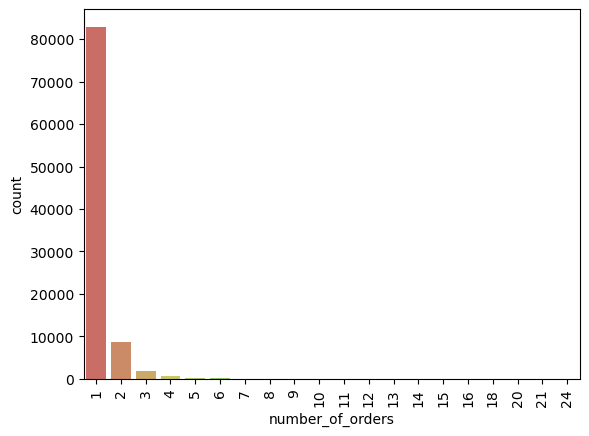

In [171]:
plt.xticks(rotation='vertical')
sns.countplot(x='number_of_orders', data=df_complete, palette='hls')

In [172]:
# Pourcentage de clients n'ayant effectué qu'une commande
df_complete.loc[df_complete['number_of_orders'] ==
                1]['number_of_orders'].sum() / df_complete.shape[0]

0.8753813832201941

In [173]:
# Nombre de clients ayant effectué plus de 5 commandes
df_complete.loc[df_complete['number_of_orders'] > 3]['number_of_orders'].sum()

6748

Plus de 87% des clients n'ont fait qu'une seule commande
7% des clients ont fait plus de 3 commandes

In [183]:
# Vérification de la cohérence des montants importants
df_complete.loc[df_complete['sum_price'] > 5000]

,number_of_orders,mean_price,sum_price,mean_score,mean_reviews,last_order,elapsed_time_days
customer_unique_id,,,,,,,
0a0a92112bd4c708ca5fde585afaa872,8,1680.0,13440.0,1.0,1.0,2017-09-29 15:24:52,1897
4007669dec559734d6f53e029e360987,6,989.1,5934.6,1.0,0.0,2017-11-24 11:03:35,1841
763c8b1c9c68a0229c42c9fc6f662b93,4,1790.0,7160.0,1.0,1.0,2018-07-15 14:49:44,1608
da122df9eeddfedc1dc1f5349a1a690c,2,3694.0,7388.0,5.0,0.0,2017-04-01 15:58:41,2078
dc4802a71eae9be1dd28f5d788ceb526,1,6735.0,6735.0,5.0,1.0,2017-02-12 20:37:36,2126
ff4159b92c40ebe40454e3e6a7c35ed6,1,6499.0,6499.0,5.0,0.0,2017-05-24 18:14:34,2025


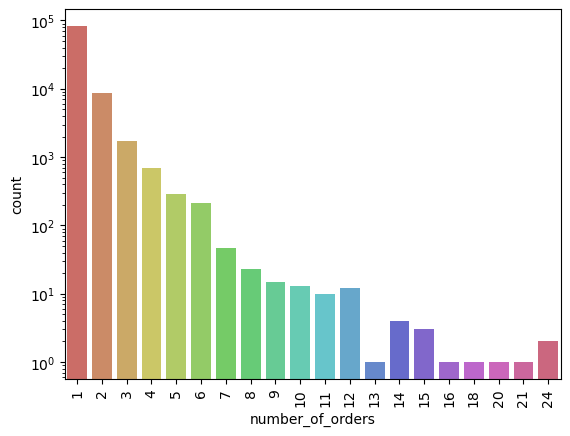

In [174]:
plt.xticks(rotation='vertical')
sns.countplot(x='number_of_orders', data=df_complete, palette='hls')
plt.yscale('log')

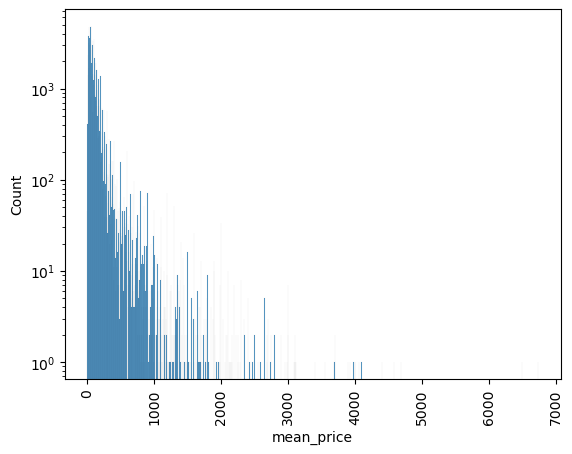

In [175]:
plt.xticks(rotation='vertical')
sns.histplot(x='mean_price', data=df_complete, palette='hls')
plt.yscale('log')

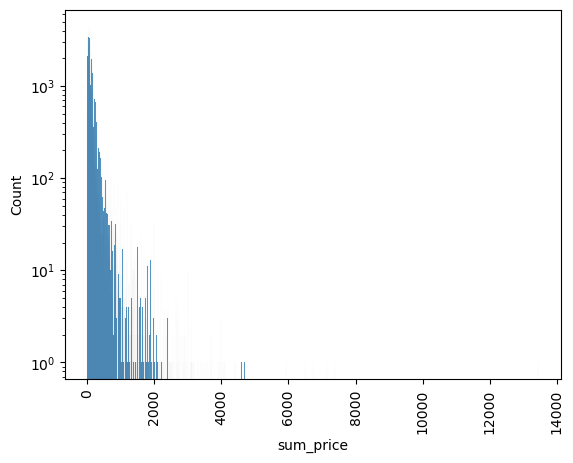

In [176]:
plt.xticks(rotation='vertical')
sns.histplot(x='sum_price', data=df_complete, palette='hls')
plt.yscale('log')

<AxesSubplot:xlabel='mean_score', ylabel='Count'>

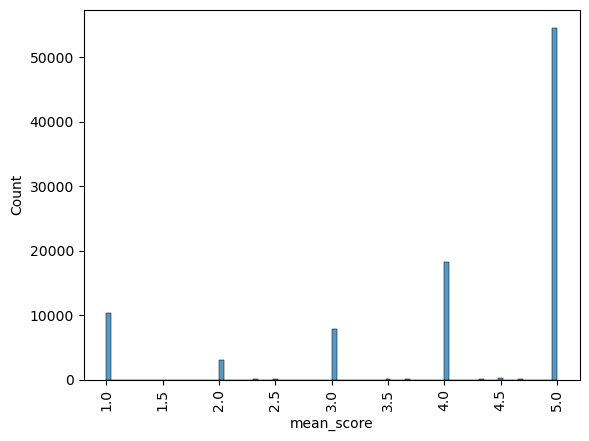

In [177]:
plt.xticks(rotation='vertical')
sns.histplot(x='mean_score', data=df_complete, palette='hls')

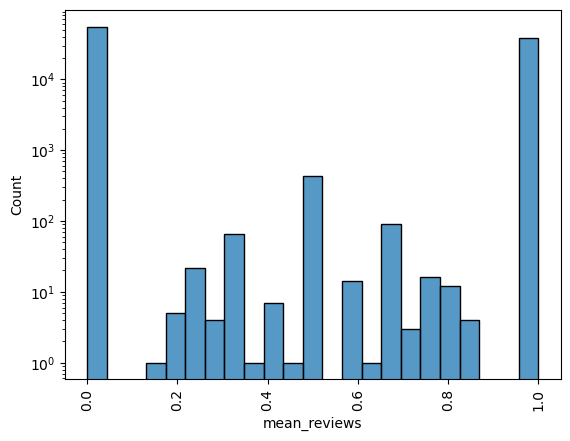

In [178]:
plt.xticks(rotation='vertical')
sns.histplot(x='mean_reviews', data=df_complete, palette='hls')
plt.yscale('log')

<AxesSubplot:xlabel='elapsed_time_days', ylabel='Count'>

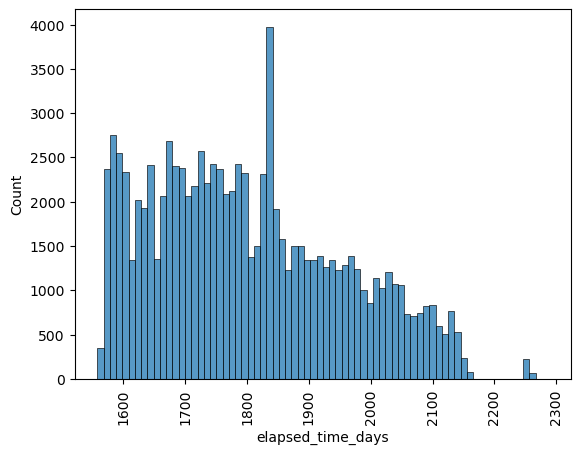

In [179]:
plt.xticks(rotation='vertical')
sns.histplot(x='elapsed_time_days', data=df_complete, palette='hls')

## Analyse bivariée

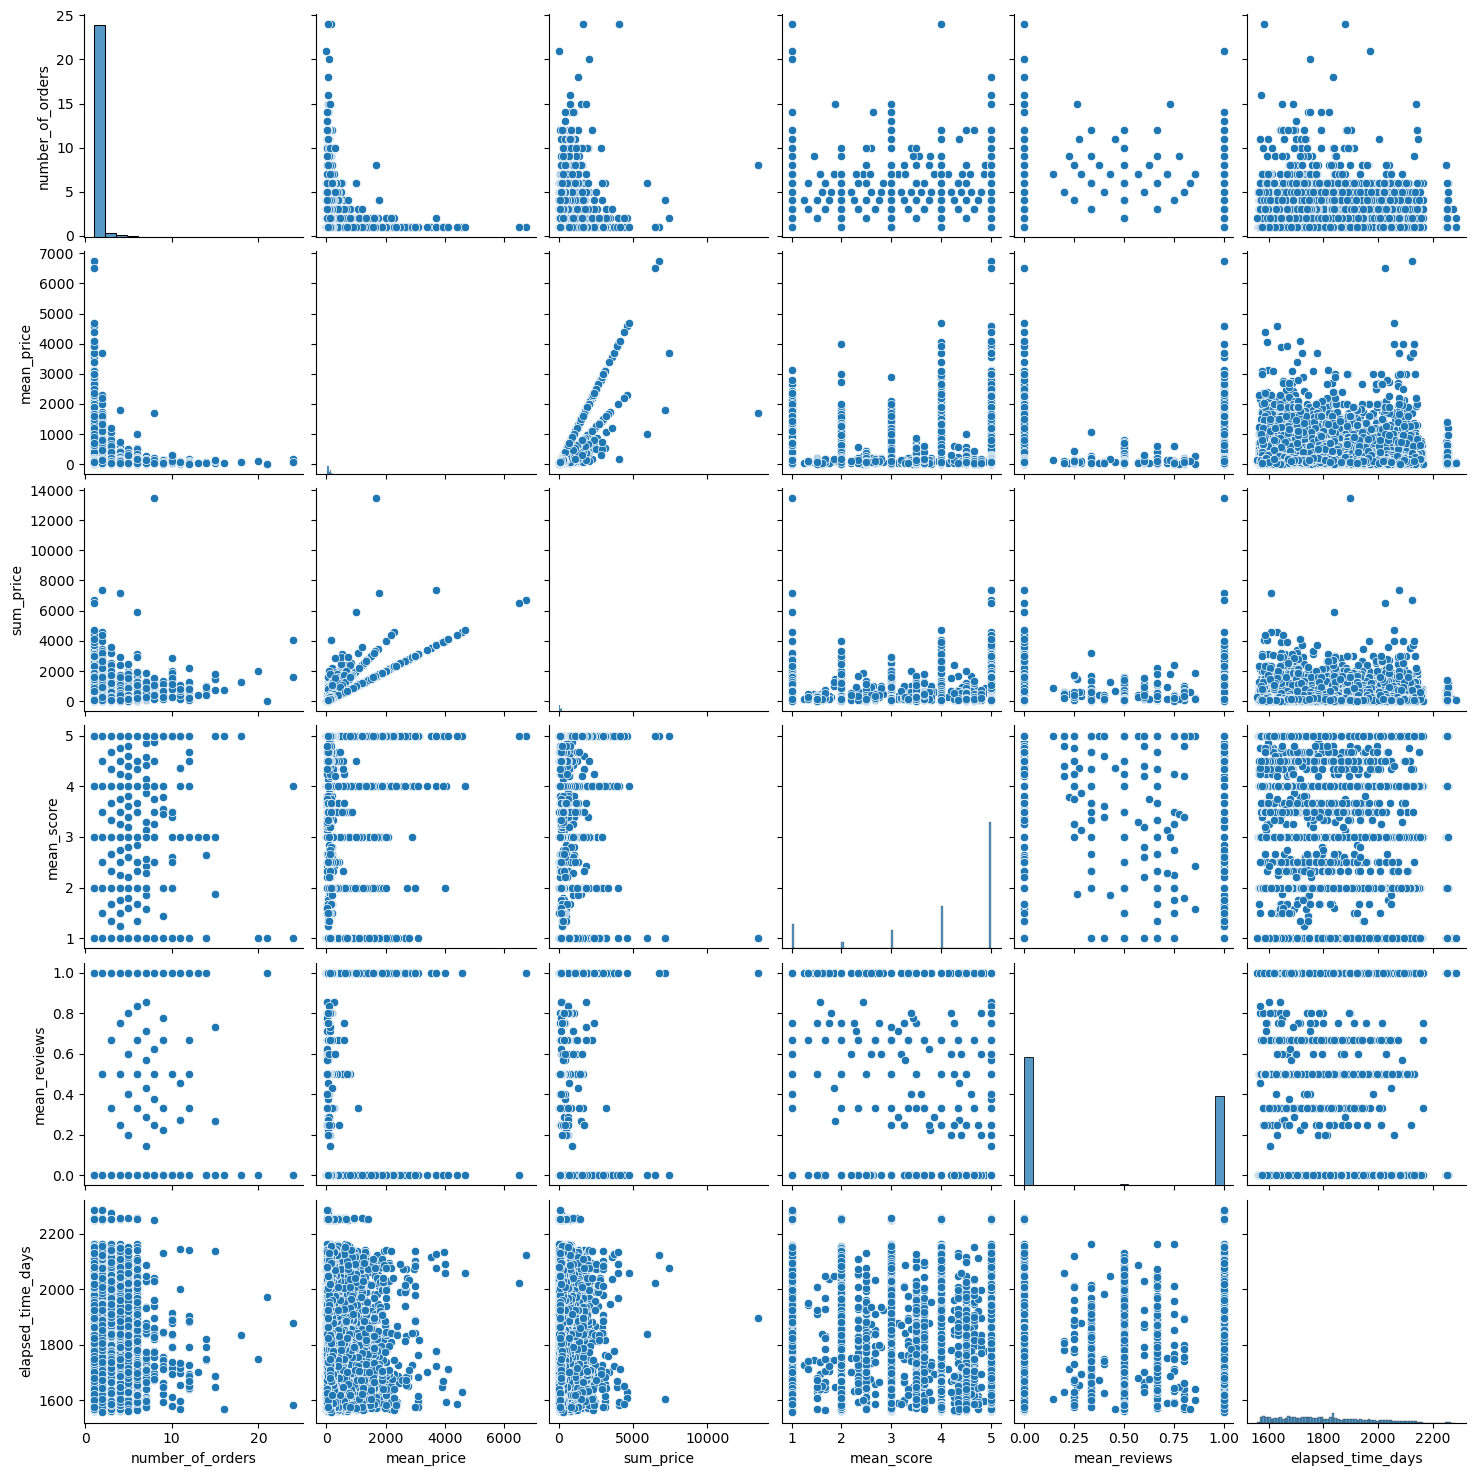

In [89]:
sns.pairplot(df_complete)

<AxesSubplot:>

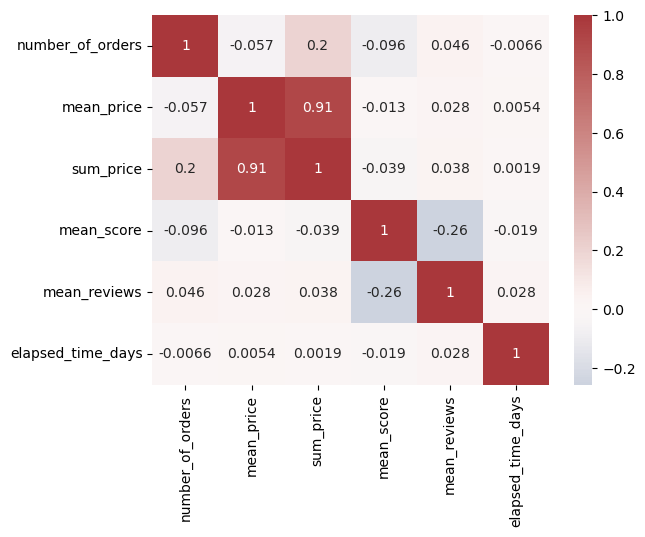

In [90]:
sns.heatmap(df_complete.corr(), center=0, cmap='vlag', annot=True, fmt='.2g')

## Feature selection

In [91]:
selection = ['elapsed_time_days', 'number_of_orders',
             'sum_price']  #, 'mean_score', 'mean_reviews']

In [92]:
df_selection = df_complete[selection]

In [93]:
df_selection.describe()

,elapsed_time_days,number_of_orders,sum_price
count,94721.000000,94721.000000,94721.000000
mean,1800.343989,1.186347,142.811254
std,153.171225,0.646716,217.714921
min,1557.000000,1.000000,0.850000
25%,1676.000000,1.000000,47.900000
50%,1781.000000,1.000000,89.900000
75%,1910.000000,1.000000,155.960000
max,2286.000000,24.000000,13440.000000
